# Calibrated GLM Posteriors: R-VGA vs. Laplace

`BayesianGLM` supports non-conjugate likelihoods (logistic, Poisson) by approximating the posterior with a Gaussian. The default strategy is the **Laplace approximation**: find the MAP estimate and match the curvature there. It is fast and usually fine, but for the logit link it has a known bias: the posterior it produces is **too narrow**, and it centers on the mode of a skewed posterior rather than the mean.

The intuition: the logistic Fisher weight $\sigma'(\eta) = \sigma(\eta)(1-\sigma(\eta))$ peaks at $\eta = 0$. Laplace evaluates it at a single point (the mode). The **R-VGA** approximation (Lambert, Bonnabel & Bach, 2022) instead averages the curvature over the current posterior, $\mathbb{E}_q[\sigma'(\eta)]$, accounting for the parameter uncertainty the point estimate ignores.

Per coordinate and per update, the difference is percent-level. It matters anyway, for two compounding reasons:

1. **Recursion**: a bandit updates one observation at a time, and each update's posterior becomes the next update's prior. A slightly over-shrunk posterior feeds an over-shrunk prior into every subsequent step.
2. **Dimension**: Thompson sampling draws *all* $p$ coefficients jointly. Small per-coordinate underestimation multiplies across coordinates into a meaningfully under-dispersed sample.

In this notebook we measure both effects: first against the exact (numerically integrated) posterior of a streaming logistic model, then as cumulative regret in a contextual bandit. See the [GLM math reference](../math/glm.rst) for the derivations.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import expit

from bayesianbandits import BayesianGLM, LaplaceApproximator, RVGAApproximator

rng = np.random.default_rng(3)

## Part 1: Tracking the exact posterior through 150 online updates

With a single coefficient we can compute the exact posterior on a grid. We stream 150 Bernoulli observations (true weight $w = 1.5$, standard normal prior) through both approximators **one at a time** via `partial_fit`, exactly how a bandit consumes data, and compare each one's posterior to the exact posterior of all data seen so far.

In [2]:
TRUE_W = 1.5
N_OBS = 150

x = rng.standard_normal(N_OBS)
y = rng.binomial(1, expit(TRUE_W * x)).astype(np.float64)

w_grid = np.linspace(-2.0, 6.0, 8001)


def exact_moments(k):
    """Mean and sd of the exact posterior given the first k observations."""
    eta = np.outer(w_grid, x[:k])
    log_post = np.sum(y[:k] * eta - np.logaddexp(0.0, eta), axis=1) - 0.5 * w_grid**2
    p = np.exp(log_post - log_post.max())
    p /= np.trapezoid(p, w_grid)
    mean = np.trapezoid(w_grid * p, w_grid)
    sd = np.sqrt(np.trapezoid((w_grid - mean) ** 2 * p, w_grid))
    return mean, sd, p


models = {
    "Laplace": BayesianGLM(alpha=1.0, link="logit", approximator=LaplaceApproximator()),
    "R-VGA": BayesianGLM(alpha=1.0, link="logit", approximator=RVGAApproximator()),
}

sd_history = {name: np.empty(N_OBS) for name in models}
exact_sd_history = np.empty(N_OBS)

for k in range(N_OBS):
    exact_sd_history[k] = exact_moments(k + 1)[1]
    for name, model in models.items():
        model.partial_fit(x[k : k + 1].reshape(1, 1), y[k : k + 1])
        sd_history[name][k] = 1.0 / np.sqrt(model.cov_inv_[0, 0])

exact_mean, exact_sd, exact_density = exact_moments(N_OBS)
print(f"After {N_OBS} single-observation updates:")
for name, model in models.items():
    sd = sd_history[name][-1]
    print(
        f"  {name:>8}: mean = {model.coef_[0]:.3f}  sd = {sd:.4f}"
        f"  (sd {100 * (sd - exact_sd) / exact_sd:+.1f}% vs exact)"
    )
print(f"  {'Exact':>8}: mean = {exact_mean:.3f}  sd = {exact_sd:.4f}")

After 150 single-observation updates:
   Laplace: mean = 1.245  sd = 0.2156  (sd -9.0% vs exact)
     R-VGA: mean = 1.330  sd = 0.2251  (sd -5.0% vs exact)
     Exact: mean = 1.303  sd = 0.2368


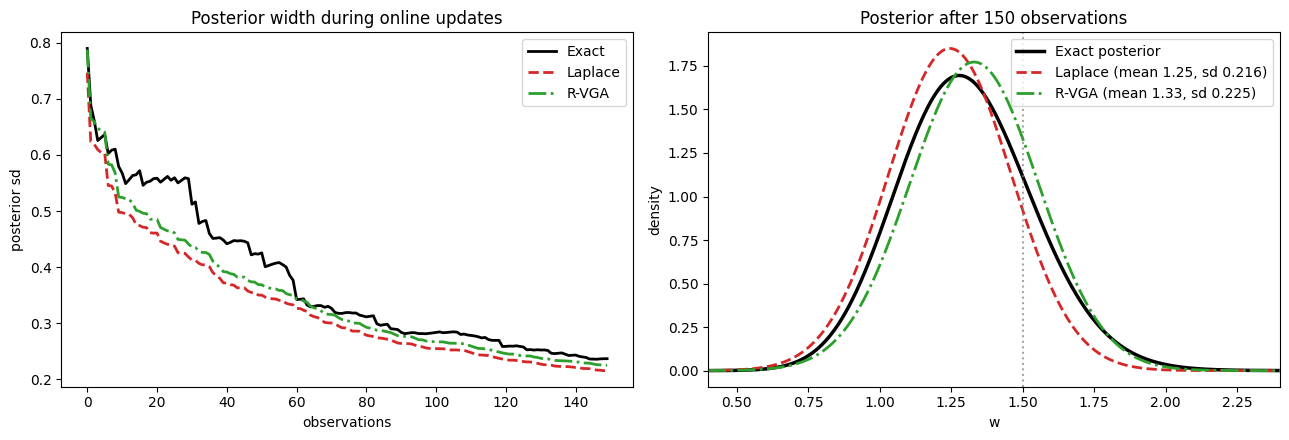

In [3]:
def gaussian_pdf(w, mean, sd):
    return np.exp(-0.5 * ((w - mean) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(exact_sd_history, "k-", linewidth=2, label="Exact")
ax1.plot(sd_history["Laplace"], "C3--", linewidth=2, label="Laplace")
ax1.plot(sd_history["R-VGA"], "C2-.", linewidth=2, label="R-VGA")
ax1.set_xlabel("observations")
ax1.set_ylabel("posterior sd")
ax1.set_title("Posterior width during online updates")
ax1.legend()

ax2.plot(w_grid, exact_density, "k-", linewidth=2.5, label="Exact posterior")
for name, color, style in [("Laplace", "C3", "--"), ("R-VGA", "C2", "-.")]:
    model = models[name]
    sd = sd_history[name][-1]
    ax2.plot(
        w_grid,
        gaussian_pdf(w_grid, model.coef_[0], sd),
        color=color,
        linestyle=style,
        linewidth=2,
        label=f"{name} (mean {model.coef_[0]:.2f}, sd {sd:.3f})",
    )
ax2.axvline(TRUE_W, color="gray", linestyle=":", alpha=0.7)
ax2.set_xlim(0.4, 2.4)
ax2.set_xlabel("w")
ax2.set_ylabel("density")
ax2.set_title(f"Posterior after {N_OBS} observations")
ax2.legend()
plt.tight_layout()
plt.show()

The Laplace posterior runs consistently below the exact width throughout the stream, and its mean sits below the exact mean (it tracks the mode of a right-skewed posterior). R-VGA tracks both noticeably better with the same per-update cost structure.

The gaps look small in one dimension. But a Thompson sampler draws all coefficients of the model jointly: if each coordinate's sd is a few percent short, the joint draw is systematically less exploratory than the data justifies, every round, with the deficit compounding through the recursion. Part 2 measures what that costs.

## Part 2: Cumulative regret under Thompson sampling

We build a 5-arm contextual bandit with binary rewards: arm $a$ pays out with probability $\sigma(\mathbf{x}^\top \mathbf{w}_a)$ for a context $\mathbf{x}$ with 4 features. All arms share one `BayesianGLM` through `LipschitzContextualAgent` with a block-sparse arm featurizer, so the model has $5 \times 4 = 20$ coefficients and updates one observation at a time.

The two agents are identical except for the `approximator`.

In [4]:
from bayesianbandits import (
    Arm,
    FunctionArmFeaturizer,
    LipschitzContextualAgent,
    ThompsonSampling,
)

N_ARMS = 5
N_FEATURES = 4  # intercept + 3 user features
P = N_ARMS * N_FEATURES

# Fixed true weights per arm
weight_rng = np.random.default_rng(7)
TRUE_WEIGHTS = weight_rng.normal(0.0, 1.0, (N_ARMS, N_FEATURES))


def block_sparse_featurizer(X, action_tokens):
    """Arm a gets the user features in the a-th block of a K*d vector."""
    n_contexts = X.shape[0]
    result = np.zeros((n_contexts, P, len(action_tokens)))
    for i, token in enumerate(action_tokens):
        result[:, token * N_FEATURES : (token + 1) * N_FEATURES, i] = X
    return result


arm_featurizer = FunctionArmFeaturizer(block_sparse_featurizer)


def make_agent(approximator, seed):
    return LipschitzContextualAgent(
        arms=[Arm(action_token=i) for i in range(N_ARMS)],
        learner=BayesianGLM(alpha=1.0, link="logit", approximator=approximator),
        policy=ThompsonSampling(),
        arm_featurizer=arm_featurizer,
        random_seed=np.random.default_rng(seed),
    )

We run 300 rounds per simulation and 50 paired simulations: within each simulation, both agents see the same context sequence and the same reward randomness, so the per-simulation regret difference isolates the effect of the approximator. Regret each round is the gap between the best arm's payout probability and the chosen arm's.

In [5]:
N_ROUNDS = 300
N_SIMS = 50

regret = {
    "Laplace": np.empty((N_SIMS, N_ROUNDS)),
    "R-VGA": np.empty((N_SIMS, N_ROUNDS)),
}

for sim in range(N_SIMS):
    sim_rng = np.random.default_rng(1000 + sim)
    contexts = np.column_stack(
        [np.ones(N_ROUNDS), sim_rng.standard_normal((N_ROUNDS, N_FEATURES - 1))]
    )
    reward_draws = sim_rng.random((N_ROUNDS, N_ARMS))  # shared across agents

    agents = {
        "Laplace": make_agent(LaplaceApproximator(), seed=sim),
        "R-VGA": make_agent(RVGAApproximator(), seed=sim),
    }

    for name, agent in agents.items():
        for t in range(N_ROUNDS):
            context = contexts[[t]]
            probs = expit(TRUE_WEIGHTS @ contexts[t])

            (action,) = agent.pull(context)
            regret[name][sim, t] = probs.max() - probs[action]

            reward = float(reward_draws[t, action] < probs[action])
            agent.select_for_update(action).update(context, np.array([reward]))

final = {name: np.cumsum(r, axis=1)[:, -1] for name, r in regret.items()}
diff = final["Laplace"] - final["R-VGA"]
se = diff.std(ddof=1) / np.sqrt(N_SIMS)
pct = 100 * diff.mean() / final["Laplace"].mean()
print(f"Mean cumulative regret after {N_ROUNDS} rounds ({N_SIMS} paired sims):")
print(f"  Laplace: {final['Laplace'].mean():.1f}")
print(f"  R-VGA:   {final['R-VGA'].mean():.1f}")
print(f"  Paired difference: {diff.mean():.1f} ± {se:.1f} (s.e.) = {pct:.0f}% lower")

Mean cumulative regret after 300 rounds (50 paired sims):
  Laplace: 34.4
  R-VGA:   32.3
  Paired difference: 2.1 ± 0.4 (s.e.) = 6% lower


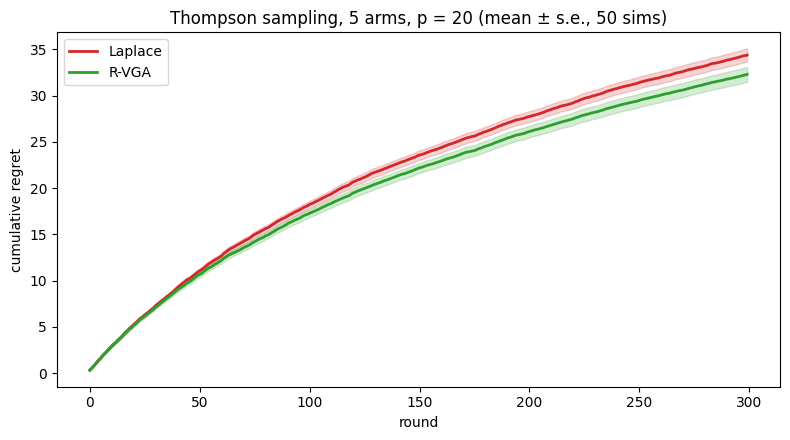

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, color in [("Laplace", "C3"), ("R-VGA", "C2")]:
    cum = np.cumsum(regret[name], axis=1)
    mean = cum.mean(axis=0)
    se_t = cum.std(axis=0, ddof=1) / np.sqrt(N_SIMS)
    ax.plot(mean, color=color, linewidth=2, label=name)
    ax.fill_between(
        np.arange(N_ROUNDS), mean - se_t, mean + se_t, color=color, alpha=0.2
    )

ax.set_xlabel("round")
ax.set_ylabel("cumulative regret")
ax.set_title(f"Thompson sampling, {N_ARMS} arms, p = {P} (mean ± s.e., {N_SIMS} sims)")
ax.legend()
plt.tight_layout()
plt.show()

The agents behave identically in the earliest rounds, where both posteriors are dominated by the prior. The gap opens as data accumulates: the Laplace agent's slightly overconfident posterior commits to arms earlier than the evidence justifies, and some of those commitments are wrong. The improvement is a steady single-digit percentage rather than a dramatic one, which is the honest size of this effect at $p = 20$; it comes essentially for free, and it grows with dimension as the joint draw involves more under-dispersed coordinates.

## Practical guidance

- **Drop-in usage**: `BayesianGLM(approximator=RVGAApproximator())`. The default uses an analytical probit approximation for the logit link; pass `use_probit=False` for Gauss-Hermite quadrature when you want maximum accuracy.
- **Cost**: each iteration additionally computes predictive variances. For dense models this is $O(p^2 n)$, negligible once the $O(p^3)$ Cholesky dominates.
- **Log link**: the expected weight $\mathbb{E}[e^\eta] = e^{m + v/2}$ is computed in closed form (no quadrature). Note the correction direction flips for the log link: expected curvature is *larger* than point curvature, so R-VGA gives narrower posteriors than Laplace for Poisson models.
- **Large sparse batches**: for `sparse=True`, batches larger than `batch_size` (default 2048) are processed as sequential minibatch updates to bound memory. This is R-VGA's native recursive mode; see the [GLM math reference](../math/glm.rst) for details.
